
# Exploración y curación del corpus de cuartetos de cuerda

Este notebook parte del corpus original y construye un subcorpus para estudiar líneas instrumentales monofónicas dentro de ensambles polifónicos

## Corpus elegido


1. Construir un corpus clásico balanceado:
   - Haydn, Op. 20, nos. 1–6;
   - Mozart, K. 387, 421, 428, 458, 464 y 465;
   - Beethoven, Op. 18, nos. 1–6.
2. Extensión romántica:
   - Schumann: 3 obras;
   - Brahms: 3 obras;
   - Dvořák: 3 obras.
3. Identificar a Debussy y Shostakovich como casos externos.


In [1]:

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)

# El notebook busca primero el archivo cargado en /mnt/data y después
# una copia situada en el mismo directorio del notebook.
CANDIDATE_PATHS = [
    Path("/mnt/data/pieces_found_by_voice_count_pitches.csv"),
    Path("pieces_found_by_voice_count_pitches.csv"),
]

CSV_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "No se encontró pieces_found_by_voice_count_pitches.csv. "
        "Modifica CANDIDATE_PATHS con la ubicación correcta."
    )

OUTPUT_DIR = Path("quartet_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH, OUTPUT_DIR.resolve()


(PosixPath('/mnt/data/pieces_found_by_voice_count_pitches.csv'),
 PosixPath('/mnt/data/quartet_outputs'))


## 1. Qué contiene realmente el archivo

Las columnas originales son:

- `filename`: nombre del MIDI;
- `composer`: etiqueta de compositor derivada del nombre;
- `ensemble`: etiqueta de ensamble derivada del nombre;
- `scope`: criterio de selección del corpus;
- `n_voices`: número de voces utilizables;
- `roles`: etiquetas de las voces;
- `min_len`, `max_len`, `mean_len`: estadísticas de longitud;
- `voices_pitches`: arreglo JSON de cuatro secuencias MIDI en el caso de un cuarteto correcto.

La descripción inicial se hace sobre todo el archivo, antes de filtrar.


In [2]:

df = pd.read_csv(CSV_PATH)

overview = pd.Series({
    "n_filas": len(df),
    "n_columnas": df.shape[1],
    "n_compositores_etiquetados": df["composer"].nunique(),
    "mediana_min_len": df["min_len"].median(),
    "minimo_min_len": df["min_len"].min(),
    "maximo_min_len": df["min_len"].max(),
    "mediana_max_len": df["max_len"].median(),
    "minimo_max_len": df["max_len"].min(),
    "maximo_max_len": df["max_len"].max(),
}, name="valor")

display(overview.to_frame())
display(pd.DataFrame({"columna": df.columns, "dtype": df.dtypes.astype(str).values}))
display(df["ensemble"].value_counts().rename_axis("ensemble").to_frame("n_filas"))
display(df["n_voices"].value_counts().sort_index().rename_axis("n_voices").to_frame("n_filas"))


,valor
n_filas,5979.0
n_columnas,10.0
n_compositores_etiquetados,108.0
mediana_min_len,167.0
minimo_min_len,50.0
maximo_min_len,7576.0
mediana_max_len,434.0
minimo_max_len,50.0
maximo_max_len,8882.0


,columna,dtype
0,filename,object
1,composer,object
2,ensemble,object
3,scope,object
4,n_voices,int64
5,roles,object
6,min_len,int64
7,max_len,int64
8,mean_len,float64
9,voices_pitches,object


,n_filas
ensemble,
other,4789
chorale,474
quartet,355
fugue,159
trio,93
duet,34
invention,30
quintet,25
canon,12


,n_filas
n_voices,
2,1276
3,1418
4,2325
5,631
6,329


In [3]:

# Validación ligera del JSON de voces y de las longitudes declaradas.
def parse_voices(value):
    voices = json.loads(value)
    if not isinstance(voices, list) or not all(isinstance(v, list) for v in voices):
        raise ValueError("voices_pitches no es una lista de listas.")
    return voices

def inspect_row_lengths(row):
    voices = parse_voices(row["voices_pitches"])
    lengths = [len(v) for v in voices]
    return pd.Series({
        "json_n_voices": len(voices),
        "json_min_len": min(lengths),
        "json_max_len": max(lengths),
        "json_mean_len": np.mean(lengths),
    })

validation_sample = pd.concat(
    [df.head(100), df.sample(min(100, len(df)), random_state=7)]
).drop_duplicates()

validation = validation_sample.apply(inspect_row_lengths, axis=1)
validation_check = pd.DataFrame({
    "n_voices_coincide": validation["json_n_voices"].eq(validation_sample["n_voices"].to_numpy()),
    "min_len_coincide": validation["json_min_len"].eq(validation_sample["min_len"].to_numpy()),
    "max_len_coincide": validation["json_max_len"].eq(validation_sample["max_len"].to_numpy()),
    "mean_len_cerca": np.isclose(
        validation["json_mean_len"],
        validation_sample["mean_len"].to_numpy(),
        atol=0.11
    ),
})

display(validation_check.mean().rename("fraccion_correcta").to_frame())


,fraccion_correcta
n_voices_coincide,1.0
min_len_coincide,1.0
max_len_coincide,1.0
mean_len_cerca,1.0



## 2. Filtro reproducible de cuartetos de cuerda

No basta con `ensemble == "quartet"`:

- hay archivos con 2, 3, 5 o 6 voces;
- aparece un cuarteto con piano etiquetado con roles de cuerda;
- algunas obras contienen la palabra *quartet* sin ser un cuarteto de cuerda para dos violines, viola y cello.

El filtro estricto exige:

- Número de voces: 4
- Roles: violin, viola, cello

y excluye nombres que indican piano o quinteto.


In [4]:

EXPECTED_ROLES = "vln I|vln II|viola|cello"

quartet_label = df[df["ensemble"].eq("quartet")].copy()

display(
    quartet_label["n_voices"]
    .value_counts()
    .sort_index()
    .rename_axis("n_voices")
    .to_frame("filas_etiquetadas_como_quartet")
)

non_string_terms = r"piano|clarinet|quintet"

strict_quartets = df.loc[
    df["ensemble"].eq("quartet")
    & df["n_voices"].eq(4)
    & df["roles"].eq(EXPECTED_ROLES)
    & ~df["filename"].str.contains(
        non_string_terms, case=False, regex=True, na=False
    )
].copy()

print(f"Filas con ensemble='quartet': {len(quartet_label)}")
print(f"Filas estrictas de cuarteto de cuerda: {len(strict_quartets)}")

composer_counts = (
    strict_quartets["composer"]
    .value_counts()
    .rename_axis("composer")
    .to_frame("n_filas")
)

display(composer_counts)


,filas_etiquetadas_como_quartet
n_voices,
2,4
3,28
4,309
5,11
6,3


Filas con ensemble='quartet': 355
Filas estrictas de cuarteto de cuerda: 308


,n_filas
composer,
haydn,146
beethoven,93
mozart,34
schumann,13
shostakovich,7
dvorak,4
tchajkowski,3
brahms,3
mendelssohn,2


In [5]:

# Diagnóstico de las filas excluidas dentro de ensemble='quartet'.
excluded_quartet_rows = quartet_label.loc[
    ~quartet_label.index.isin(strict_quartets.index),
    ["filename", "composer", "n_voices", "roles", "min_len", "max_len"]
].sort_values(["composer", "filename"])

display(excluded_quartet_rows)


,filename,composer,n_voices,roles,min_len,max_len
2290,bach_trio_(quartet)_sonatas_1036_(c)harfesoft.mid,bach_js,5,voice_1|voice_2|voice_3|voice_4|voice_5,803,1638
2291,bach_trio_(quartet)_sonatas_1037_(c)harfesoft.mid,bach_js,5,voice_1|voice_2|voice_3|voice_4|voice_5,1461,2405
2292,bach_trio_(quartet)_sonatas_1038_(c)harfesoft.mid,bach_js,5,voice_1|voice_2|voice_3|voice_4|voice_5,897,1032
2293,bach_trio_(quartet)_sonatas_1039_(c)harfesoft.mid,bach_js,5,voice_1|voice_2|voice_3|voice_4|voice_5,1416,2467
2294,bach_trio_(quartet)_sonatas_997_(c)harfesoft.mid,bach_js,6,voice_1|voice_2|voice_3|voice_4|voice_5|voice_6,1486,2769
4110,beethoven_string_quartet_18_4_1_(c)unknown.mid,beethoven,3,upper|middle|lower,1331,1520
4111,beethoven_string_quartet_18_4_2_(c)unknown.mid,beethoven,3,upper|middle|lower,719,880
4112,beethoven_string_quartet_18_4_3_(c)unknown.mid,beethoven,3,upper|middle|lower,345,639
4113,beethoven_string_quartet_18_4_4_(c)unknown.mid,beethoven,3,upper|middle|lower,792,1203
5008,brahms_quintet_for_clarinet_string_quartet_115_(c)harfesoft.mid,brahms,5,voice_1|voice_2|voice_3|voice_4|voice_5,3206,4809



## 3. Normalización inicial de metadatos

La etiqueta del compositor proviene del nombre del archivo y no siempre usa la grafía estándar. Por ejemplo, `tchajkowski` se normaliza como **Pyotr Ilyich Tchaikovsky**.

Estas columnas son todavía metadatos generales del conjunto de 308 candidatos. La identificación exacta de obra, catálogo y movimiento se hará manualmente para el subcorpus elegido, porque una expresión regular universal confundiría números de obra con números de movimiento.


In [6]:

CANONICAL_COMPOSER = {
    "haydn": "Joseph Haydn",
    "mozart": "Wolfgang Amadeus Mozart",
    "beethoven": "Ludwig van Beethoven",
    "schumann": "Robert Schumann",
    "brahms": "Johannes Brahms",
    "dvorak": "Antonín Dvořák",
    "tchajkowski": "Pyotr Ilyich Tchaikovsky",
    "mendelssohn": "Felix Mendelssohn",
    "bruckner": "Anton Bruckner",
    "grieg": "Edvard Grieg",
    "debussy": "Claude Debussy",
    "shostakovich": "Dmitri Shostakovich",
}

PERIOD_MAP = {
    "haydn": "Classical",
    "mozart": "Classical",
    "beethoven": "Classical / transitional",
    "schumann": "Romantic",
    "brahms": "Romantic",
    "dvorak": "Romantic",
    "tchajkowski": "Romantic",
    "mendelssohn": "Romantic",
    "bruckner": "Romantic",
    "grieg": "Romantic",
    "debussy": "Late 19th century / fin-de-siècle",
    "shostakovich": "20th century",
}

def extract_edition_source(filename):
    match = re.search(r"_\((?:c|nc)\)([^.]+)\.mid$", filename, flags=re.I)
    return match.group(1) if match else "unknown"

strict_quartets["composer_canonical"] = strict_quartets["composer"].map(
    CANONICAL_COMPOSER
).fillna(strict_quartets["composer"].str.title())

strict_quartets["period"] = strict_quartets["composer"].map(PERIOD_MAP).fillna("Inspect")
strict_quartets["genre"] = "string_quartet"
strict_quartets["instrumentation"] = "2vn-va-vc"
strict_quartets["edition_source"] = strict_quartets["filename"].map(extract_edition_source)

# Esta clasificación es deliberadamente preliminar.
movement_sources = {
    "simonetto", "edwards", "mutopia",
    "wittenburg", "onclassical", "bachovich"
}

strict_quartets["file_unit_preliminary"] = np.where(
    strict_quartets["edition_source"].isin(movement_sources),
    "movement_or_segment",
    np.where(
        strict_quartets["edition_source"].eq("harfesoft"),
        "usually_complete_work",
        "inspect"
    )
)

display(
    strict_quartets[
        ["composer_canonical", "period", "edition_source", "file_unit_preliminary"]
    ]
    .value_counts()
    .rename("n_filas")
    .reset_index()
)


,composer_canonical,period,edition_source,file_unit_preliminary,n_filas
0,Joseph Haydn,Classical,edwards,movement_or_segment,79
1,Ludwig van Beethoven,Classical / transitional,edwards,movement_or_segment,69
2,Joseph Haydn,Classical,simonetto,movement_or_segment,44
3,Wolfgang Amadeus Mozart,Classical,mutopia,movement_or_segment,24
4,Joseph Haydn,Classical,harfesoft,usually_complete_work,22
5,Ludwig van Beethoven,Classical / transitional,harfesoft,usually_complete_work,19
6,Wolfgang Amadeus Mozart,Classical,wittenburg,movement_or_segment,10
7,Robert Schumann,Romantic,onclassical,movement_or_segment,10
8,Dmitri Shostakovich,20th century,bachovich,movement_or_segment,7
9,Ludwig van Beethoven,Classical / transitional,wittenburg,movement_or_segment,4



## 4. Movimientos, obras completas y ediciones duplicadas

La unidad estadística debe ser la obra, pero el archivo mezcla dos representaciones:

- **movimientos separados:** varias filas por obra;
- **obra completa:** una fila que ya contiene todos los movimientos.

No deben contarse ambas ediciones como obras independientes.

### Decisiones de edición para el corpus elegido

| Repertorio | Alternativas detectadas | Edición elegida | Razón |
|---|---|---|---|
| Haydn Op. 20 | Simonetto por movimientos / Harfesoft completa | Simonetto | conserva los cuatro movimientos y permite análisis por movimiento y por obra |
| Mozart K. 387 | Wittenburg incompleta / Mutopia completa | Mutopia | contiene los cuatro movimientos y es consistente con los otros cinco cuartetos |
| Beethoven Op. 18 | Edwards por movimientos / Harfesoft completa | Edwards | conserva límites de movimiento para los seis cuartetos |
| Schumann Op. 41 | OnClassical por movimientos / Harfesoft completa | Harfesoft | varios movimientos OnClassical fueron extraídos con cinco voces; Harfesoft mantiene cuatro voces |

Para análisis exclusivamente global puede compararse la edición seleccionada con la edición alternativa como prueba de robustez.


In [7]:

edition_checks = pd.concat([
    df[df["filename"].str.contains(
        r"haydn_(?:string_)?quartet_20_", case=False, regex=True, na=False
    )],
    df[df["filename"].str.contains(
        r"mozart_string[-_]quartet_387_", case=False, regex=True, na=False
    )],
    df[df["filename"].str.contains(
        r"beethoven_(?:string_)?quartet_(?:18_|[1-6]_)",
        case=False, regex=True, na=False
    )],
    df[df["filename"].str.contains(
        r"schumann_(?:string_)?quartet_41", case=False, regex=True, na=False
    )],
]).drop_duplicates()

display(
    edition_checks[
        ["filename", "composer", "n_voices", "roles", "min_len", "max_len"]
    ].sort_values(["composer", "filename"])
)


,filename,composer,n_voices,roles,min_len,max_len
3995,beethoven_quartet_1_1_(c)edwards.mid,beethoven,4,vln I|vln II|viola|cello,984,1901
3996,beethoven_quartet_1_2_(c)edwards.mid,beethoven,4,vln I|vln II|viola|cello,610,862
3997,beethoven_quartet_1_3_(c)edwards.mid,beethoven,4,vln I|vln II|viola|cello,686,957
3998,beethoven_quartet_1_4_(c)edwards.mid,beethoven,4,vln I|vln II|viola|cello,1084,1633
3999,beethoven_quartet_2_1_(c)edwards.mid,beethoven,4,vln I|vln II|viola|cello,762,1416
...,...,...,...,...,...,...
4560,schumann_quartet_41-3_3_(c)onclassical.mid,schumann,5,voice_1|voice_2|voice_3|voice_4|voice_5,95,652
4561,schumann_quartet_41-3_4_(c)onclassical.mid,schumann,4,vln I|vln II|viola|cello,1465,1892
4570,schumann_string_quartet_41_1_(c)harfesoft.mid,schumann,4,vln I|vln II|viola|cello,2570,4278
4571,schumann_string_quartet_41_2_(c)harfesoft.mid,schumann,4,vln I|vln II|viola|cello,2439,4339


El corpus de clasicismo contiene 18 obras:

$$
3\ \text{compositores}
\times
6\ \text{cuartetos}
=
18\ \text{obras},
$$

$$
18\ \text{obras}
\times
4\ \text{voces}
=
72\ \text{series instrumentales}.
$$

### Obras

- **Haydn, Op. 20:**.
- **Mozart, seis cuartetos dedicados a Haydn:** .
- **Beethoven, Op. 18:** .



In [8]:

def add_metadata(
    row,
    *,
    work_id,
    catalogue,
    work_title,
    composer_canonical,
    period,
    corpus_group,
    file_unit,
    movement_no,
    edition_source,
    is_complete,
    analysis_status="include",
    selection_reason="",
):
    record = row.to_dict()
    record.update({
        "composer_canonical": composer_canonical,
        "period": period,
        "genre": "string_quartet",
        "instrumentation": "2vn-va-vc",
        "work_id": work_id,
        "catalogue": catalogue,
        "work_title": work_title,
        "movement_no": movement_no,
        "file_unit": file_unit,
        "edition_source": edition_source,
        "is_complete_work_in_selected_edition": is_complete,
        "corpus_group": corpus_group,
        "analysis_status": analysis_status,
        "selection_reason": selection_reason,
    })
    return record

selected_records = []

# Haydn Op. 20: Simonetto, cuatro movimientos por obra.
for number in range(1, 7):
    pattern = rf"^haydn_quartet_20_{number}_([1-4])_\(c\)simonetto\.mid$"
    subset = strict_quartets[strict_quartets["filename"].str.match(pattern)]
    assert len(subset) == 4, (number, len(subset))

    for _, row in subset.iterrows():
        movement = int(re.match(pattern, row["filename"]).group(1))
        selected_records.append(add_metadata(
            row,
            work_id=f"haydn_op20_no{number}",
            catalogue=f"Op. 20 No. {number}",
            work_title=f"String Quartet Op. 20 No. {number}",
            composer_canonical="Joseph Haydn",
            period="Classical",
            corpus_group="classical_core",
            file_unit="movement",
            movement_no=movement,
            edition_source="simonetto",
            is_complete=True,
            selection_reason=(
                "Conjunto balanceado de seis obras; la edición conserva "
                "los límites entre movimientos."
            ),
        ))

# Mozart: seis cuartetos, edición Mutopia completa.
for k_number in [387, 421, 428, 458, 464, 465]:
    pattern = rf"^mozart_string_quartet_{k_number}_([1-4])_\(nc\)mutopia\.mid$"
    subset = strict_quartets[strict_quartets["filename"].str.match(pattern)]
    assert len(subset) == 4, (k_number, len(subset))

    for _, row in subset.iterrows():
        movement = int(re.match(pattern, row["filename"]).group(1))
        selected_records.append(add_metadata(
            row,
            work_id=f"mozart_k{k_number}",
            catalogue=f"K. {k_number}",
            work_title=f"String Quartet K. {k_number}",
            composer_canonical="Wolfgang Amadeus Mozart",
            period="Classical",
            corpus_group="classical_core",
            file_unit="movement",
            movement_no=movement,
            edition_source="mutopia",
            is_complete=True,
            selection_reason=(
                "Uno de los seis cuartetos dedicados a Haydn; "
                "edición completa de cuatro movimientos."
            ),
        ))

# Beethoven Op. 18: Edwards, cuatro movimientos por obra.
for number in range(1, 7):
    pattern = rf"^beethoven_quartet_{number}_([1-4])_\(c\)edwards\.mid$"
    subset = strict_quartets[strict_quartets["filename"].str.match(pattern)]
    assert len(subset) == 4, (number, len(subset))

    for _, row in subset.iterrows():
        movement = int(re.match(pattern, row["filename"]).group(1))
        selected_records.append(add_metadata(
            row,
            work_id=f"beethoven_op18_no{number}",
            catalogue=f"Op. 18 No. {number}",
            work_title=f"String Quartet Op. 18 No. {number}",
            composer_canonical="Ludwig van Beethoven",
            period="Classical / transitional",
            corpus_group="classical_core",
            file_unit="movement",
            movement_no=movement,
            edition_source="edwards",
            is_complete=True,
            selection_reason=(
                "Conjunto cerrado de seis obras; la edición conserva "
                "los límites entre movimientos."
            ),
        ))



## 6. Extensión romántica

Se añaden nueve obras, balanceadas como tres cuartetos por compositor:

- Schumann: Op. 41, nos. 1–3;
- Brahms: Op. 51, nos. 1–2, y Op. 67;
- Dvořák: Op. 51, Op. 96 y Op. 105.

Este bloque sí permite contrastar el corpus clásico con un bloque romántico, pero el modelo debe reconocer que:

- las obras están agrupadas por compositor;
- las ediciones románticas elegidas contienen la obra completa en una sola fila.

El cuarto cuarteto disponible de Dvořák, Op. 61, queda como obra de reserva para pruebas de sensibilidad, no en el diseño balanceado principal.


In [9]:

romantic_works = [
    (
        "schumann_string_quartet_41_1_(c)harfesoft.mid",
        "schumann_op41_no1", "Op. 41 No. 1",
        "String Quartet Op. 41 No. 1", "Robert Schumann"
    ),
    (
        "schumann_string_quartet_41_2_(c)harfesoft.mid",
        "schumann_op41_no2", "Op. 41 No. 2",
        "String Quartet Op. 41 No. 2", "Robert Schumann"
    ),
    (
        "schumann_string_quartet_41_3_(c)harfesoft.mid",
        "schumann_op41_no3", "Op. 41 No. 3",
        "String Quartet Op. 41 No. 3", "Robert Schumann"
    ),
    (
        "brahms_string_quartet_51_1_(c)harfesoft.mid",
        "brahms_op51_no1", "Op. 51 No. 1",
        "String Quartet Op. 51 No. 1", "Johannes Brahms"
    ),
    (
        "brahms_string_quartet_51_2_(c)harfesoft.mid",
        "brahms_op51_no2", "Op. 51 No. 2",
        "String Quartet Op. 51 No. 2", "Johannes Brahms"
    ),
    (
        "brahms_string_quartet_67_(c)harfesoft.mid",
        "brahms_op67", "Op. 67",
        "String Quartet Op. 67", "Johannes Brahms"
    ),
    (
        "dvorak_string_quartet_51_(c)harfesoft.mid",
        "dvorak_op51", "Op. 51",
        "String Quartet Op. 51", "Antonín Dvořák"
    ),
    (
        "dvorak_string_quartet_96_(c)harfesoft.mid",
        "dvorak_op96", "Op. 96",
        "String Quartet Op. 96", "Antonín Dvořák"
    ),
    (
        "dvorak_string_quartet_105_(c)harfesoft.mid",
        "dvorak_op105", "Op. 105",
        "String Quartet Op. 105", "Antonín Dvořák"
    ),
]

for filename, work_id, catalogue, title, composer_name in romantic_works:
    subset = strict_quartets[strict_quartets["filename"].eq(filename)]
    assert len(subset) == 1, filename
    row = subset.iloc[0]

    selected_records.append(add_metadata(
        row,
        work_id=work_id,
        catalogue=catalogue,
        work_title=title,
        composer_canonical=composer_name,
        period="Romantic",
        corpus_group="romantic_extension",
        file_unit="complete_work",
        movement_no=pd.NA,
        edition_source="harfesoft",
        is_complete=True,
        selection_reason=(
            "Tres obras por compositor para construir una extensión "
            "romántica balanceada."
        ),
    ))



## 7. Debussy y Shostakovich como casos externos

El corpus moderno es demasiado pequeño para estimar un efecto general del siglo XX.

Se incluyen como **casos de estudio**, no como un periodo balanceado:

- Debussy, Op. 10: una obra de 1893, útil como caso de transición hacia lenguajes modernos;
- Shostakovich, Op. 49: cuatro movimientos correctamente extraídos.

El cuarteto de Shostakovich Op. 73 requiere reparación:

- movimientos 1, 2 y 4: cuatro voces;
- movimientos 3 y 5: cinco voces.

No debe concatenarse como cuarteto limpio antes de revisar los tracks MIDI originales.


In [10]:

# Debussy Op. 10.
filename = "debussy_string_quartet_10_(c)harfesoft.mid"
row = strict_quartets[strict_quartets["filename"].eq(filename)].iloc[0]

selected_records.append(add_metadata(
    row,
    work_id="debussy_op10",
    catalogue="Op. 10",
    work_title="String Quartet Op. 10",
    composer_canonical="Claude Debussy",
    period="Late 19th century / fin-de-siècle",
    corpus_group="modern_case_study",
    file_unit="complete_work",
    movement_no=pd.NA,
    edition_source="harfesoft",
    is_complete=True,
    analysis_status="case_study",
    selection_reason=(
        "Única obra completa de Debussy; se usa como caso externo, "
        "no como muestra de un periodo."
    ),
))

# Shostakovich Op. 49.
for movement in range(1, 5):
    filename = (
        f"shostakovich_string_quartet_49_{movement}_(c)bachovich.mid"
    )
    row = strict_quartets[strict_quartets["filename"].eq(filename)].iloc[0]

    selected_records.append(add_metadata(
        row,
        work_id="shostakovich_op49",
        catalogue="Op. 49",
        work_title="String Quartet No. 1, Op. 49",
        composer_canonical="Dmitri Shostakovich",
        period="20th century",
        corpus_group="modern_case_study",
        file_unit="movement",
        movement_no=movement,
        edition_source="bachovich",
        is_complete=True,
        analysis_status="case_study",
        selection_reason=(
            "Obra completa de cuatro movimientos; se usa como caso "
            "moderno externo."
        ),
    ))

curated_files = pd.DataFrame(selected_records)

print("Archivos seleccionados:", len(curated_files))
print("Obras distintas:", curated_files["work_id"].nunique())

display(
    curated_files.groupby(
        ["corpus_group", "composer_canonical"]
    ).agg(
        n_archivos=("filename", "size"),
        n_obras=("work_id", "nunique"),
    )
)


Archivos seleccionados: 86
Obras distintas: 29


n_archivos  n_obras
corpus_group       composer_canonical                          
classical_core     Joseph Haydn                     24        6
                   Ludwig van Beethoven             24        6
                   Wolfgang Amadeus Mozart          24        6
modern_case_study  Claude Debussy                    1        1
                   Dmitri Shostakovich               4        1
romantic_extension Antonín Dvořák                    3        3
                   Johannes Brahms                   3        3
                   Robert Schumann                   3        3

In [11]:

# Diagnóstico separado del Op. 73 de Shostakovich.
repair_candidates = df[
    df["filename"].str.match(
        r"^shostakovich_string_quartet_73_[1-5]_\(c\)bachovich\.mid$"
    )
].copy()

repair_candidates["composer_canonical"] = "Dmitri Shostakovich"
repair_candidates["period"] = "20th century"
repair_candidates["genre"] = "string_quartet"
repair_candidates["instrumentation"] = "2vn-va-vc"
repair_candidates["work_id"] = "shostakovich_op73"
repair_candidates["catalogue"] = "Op. 73"
repair_candidates["work_title"] = "String Quartet No. 3, Op. 73"
repair_candidates["edition_source"] = "bachovich"
repair_candidates["analysis_status"] = "repair_required"
repair_candidates["repair_note"] = np.where(
    repair_candidates["n_voices"].eq(4),
    "Número de voces correcto; conservar después de revisar toda la obra.",
    "Extracción con cinco voces; volver al MIDI y fusionar tracks."
)

display(
    repair_candidates[
        [
            "filename", "n_voices", "roles",
            "min_len", "max_len", "repair_note"
        ]
    ]
)


,filename,n_voices,roles,min_len,max_len,repair_note
5935,shostakovich_string_quartet_73_1_(c)bachovich.mid,4,vln I|vln II|viola|cello,760,1477,Número de voces correcto; conservar después de revisar toda la obra.
5936,shostakovich_string_quartet_73_2_(c)bachovich.mid,4,vln I|vln II|viola|cello,427,570,Número de voces correcto; conservar después de revisar toda la obra.
5937,shostakovich_string_quartet_73_3_(c)bachovich.mid,5,voice_1|voice_2|voice_3|voice_4|voice_5,50,831,Extracción con cinco voces; volver al MIDI y fusionar tracks.
5938,shostakovich_string_quartet_73_4_(c)bachovich.mid,4,vln I|vln II|viola|cello,155,216,Número de voces correcto; conservar después de revisar toda la obra.
5939,shostakovich_string_quartet_73_5_(c)bachovich.mid,5,voice_1|voice_2|voice_3|voice_4|voice_5,190,1152,Extracción con cinco voces; volver al MIDI y fusionar tracks.



## 8. Concatenación de movimientos y construcción de una fila por obra

Para cada obra:

1. se ordenan los movimientos;
2. se convierte `voices_pitches` desde JSON;
3. se concatenan por separado violín I, violín II, viola y cello;
4. se recalculan las longitudes;
5. se conservan los nombres de todos los archivos fuente.

La concatenación se usa para medidas globales. La tabla `curated_files` conserva los movimientos, por lo que también puede hacerse análisis formal por movimiento.


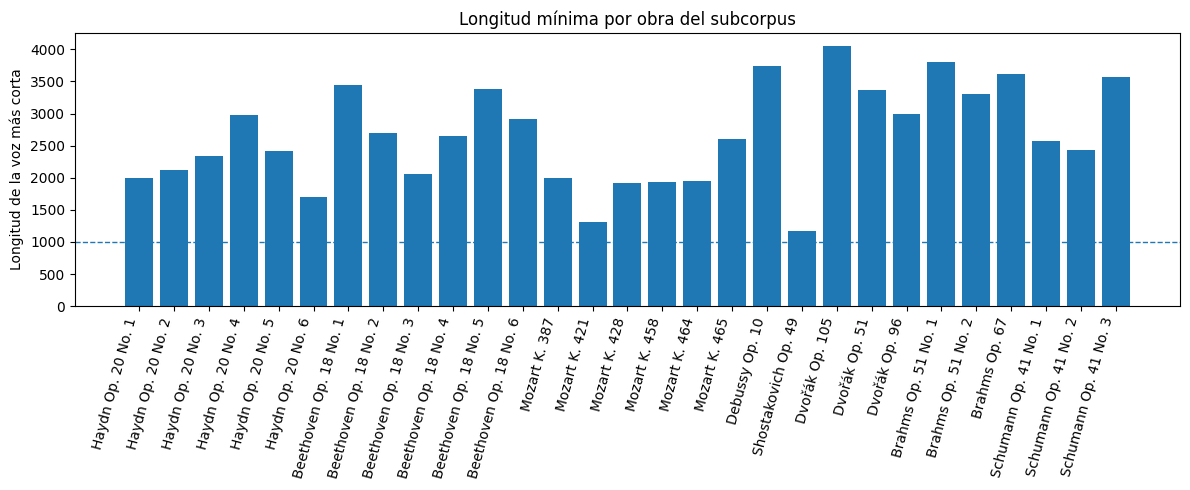

In [15]:

# Longitud de la voz más corta por obra del corpus curado.
plot_data = curated_works.sort_values(
    ["corpus_group", "composer_canonical", "catalogue"]
).copy()

labels = (
    plot_data["composer_canonical"].str.split().str[-1]
    + " "
    + plot_data["catalogue"]
)

plt.figure(figsize=(12, 5))
plt.bar(np.arange(len(plot_data)), plot_data["min_len_work"])
plt.axhline(1000, linestyle="--", linewidth=1)
plt.xticks(np.arange(len(plot_data)), labels, rotation=75, ha="right")
plt.ylabel("Longitud de la voz más corta")
plt.title("Longitud mínima por obra del subcorpus")
plt.tight_layout()
plt.show()


In [16]:

# Comparación de las cuatro voces por compositor.
voice_length_table = curated_works.melt(
    id_vars=[
        "work_id", "composer_canonical",
        "period", "corpus_group", "catalogue"
    ],
    value_vars=["vln_I_len", "vln_II_len", "viola_len", "cello_len"],
    var_name="voice",
    value_name="n_notes",
)

display(
    voice_length_table.groupby(
        ["corpus_group", "composer_canonical", "voice"]
    )["n_notes"].agg(["count", "median", "min", "max"])
)


count  median   min  \
corpus_group       composer_canonical      voice                             
classical_core     Joseph Haydn            cello_len       6  2291.5  1698   
                                           viola_len       6  2376.5  1992   
                                           vln_II_len      6  2884.5  2186   
                                           vln_I_len       6  3924.0  3157   
                   Ludwig van Beethoven    cello_len       6  2902.0  2057   
                                           viola_len       6  3453.5  2698   
                                           vln_II_len      6  3717.0  3124   
                                           vln_I_len       6  4749.0  3558   
                   Wolfgang Amadeus Mozart cello_len       6  1939.5  1318   
                                           viola_len       6  2340.0  1938   
                                           vln_II_len      6  2630.0  2070   
                                           vln_I_len       6  2871.0  2379   
modern_case_study  Claude Debussy          cello_len       1  3747.0  3747   
                                           viola_len       1  5225.0  5225   
                                           vln_II_len      1  5133.0  5133   
                                           vln_I_len       1  3911.0  3911   
                   Dmitri Shostakovich     cello_len       1  1178.0  1178   
                                           viola_len       1  1964.0  1964   
                                           vln_II_len      1  1986.0  1986   
                                           vln_I_len       1  1978.0  1978   
romantic_extension Antonín Dvořák          cello_len       3  3360.0  2997   
                                           viola_len       3  4858.0  4380   
                                           vln_II_len      3  4583.0  4238   
                                           vln_I_len       3  4689.0  4059   
                   Johannes Brahms         cello_len       3  3612.0  3303   
                                           viola_len       3  4568.0  4523   
                                           vln_II_len      3  4006.0  3979   
                                           vln_I_len       3  4897.0  4289   
                   Robert Schumann         cello_len       3  2570.0  2439   
                                           viola_len       3  4023.0  3403   
                                           vln_II_len      3  3877.0  3257   
                                           vln_I_len       3  4278.0  4044   

                                                        max  
corpus_group       composer_canonical      voice             
classical_core     Joseph Haydn            cello_len   3492  
                                           viola_len   2975  
                                           vln_II_len  3348  
                                           vln_I_len   5164  
                   Ludwig van Beethoven    cello_len   3438  
                                           viola_len   4219  
                                           vln_II_len  4325  
                                           vln_I_len   5889  
                   Wolfgang Amadeus Mozart cello_len   2603  
                                           viola_len   2807  
                                           vln_II_len  3238  
                                           vln_I_len   3680  
modern_case_study  Claude Debussy          cello_len   3747  
                                           viola_len   5225  
                                           vln_II_len  5133  
                                           vln_I_len   3911  
                   Dmitri Shostakovich     cello_len   1178  
                                           viola_len   1964  
                                           vln_II_len  1986  
                                           vln_I_len   1978  
romantic_extension Antonín Dvořák     


## 10. Columnas nuevas del subcorpus

La tabla por archivos añade:

- `composer_canonical`;
- `period`;
- `genre`;
- `instrumentation`;
- `work_id`;
- `catalogue`;
- `work_title`;
- `movement_no`;
- `file_unit`;
- `edition_source`;
- `is_complete_work_in_selected_edition`;
- `corpus_group`;
- `analysis_status`;
- `selection_reason`.

La tabla por obras añade además:

- longitudes por instrumento;
- `min_len_work`, `max_len_work`, `mean_len_work`;
- `n_windows_512`;
- `passes_min_1000`;
- archivos fuente;
- secuencias concatenadas.

### Grupos del corpus

- `classical_core`: corpus principal de 18 obras;
- `romantic_extension`: extensión balanceada de 9 obras;
- `modern_case_study`: Debussy y Shostakovich Op. 49;
- `repair_required`: archivos que no deben entrar al análisis antes de corregirse.


In [17]:

# Reordenamiento de columnas antes de exportar.
file_metadata_columns = [
    "work_id", "composer", "composer_canonical", "period",
    "genre", "instrumentation", "catalogue", "work_title",
    "corpus_group", "analysis_status", "selection_reason",
    "file_unit", "movement_no", "edition_source",
    "is_complete_work_in_selected_edition",
]

original_columns = [
    "filename", "ensemble", "scope", "n_voices", "roles",
    "min_len", "max_len", "mean_len", "voices_pitches",
]

curated_files_export = curated_files[
    file_metadata_columns + original_columns
].sort_values(
    ["corpus_group", "composer_canonical", "work_id", "movement_no"],
    na_position="last"
)

strict_export = strict_quartets.sort_values(
    ["composer_canonical", "filename"]
)

works_export = curated_works.sort_values(
    ["corpus_group", "composer_canonical", "work_id"]
)

repair_export = repair_candidates.sort_values("filename")

strict_path = OUTPUT_DIR / "quartet_strict_candidates.csv"
files_path = OUTPUT_DIR / "quartet_subcorpus_files.csv"
works_path = OUTPUT_DIR / "quartet_subcorpus_works.csv"
repair_path = OUTPUT_DIR / "quartet_repair_candidates.csv"

strict_export.to_csv(strict_path, index=False)
curated_files_export.to_csv(files_path, index=False)
works_export.to_csv(works_path, index=False)
repair_export.to_csv(repair_path, index=False)

for output_path in [strict_path, files_path, works_path, repair_path]:
    print(output_path.resolve())


/mnt/data/quartet_outputs/quartet_strict_candidates.csv
/mnt/data/quartet_outputs/quartet_subcorpus_files.csv
/mnt/data/quartet_outputs/quartet_subcorpus_works.csv
/mnt/data/quartet_outputs/quartet_repair_candidates.csv
